In [1]:
print("Suraj")

Suraj


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df = pd.read_excel(r"C:\MLOPs_Machine_Learning_Projects\Customer_Churn_Prediction_MLOps_Pipeline\notebook\Telco_customer_churn.xlsx")


In [75]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [76]:
df.shape

(7043, 33)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [78]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [79]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [80]:
# define numerical & categorical columns
# Sare Numerical cols and categorical cols ko alag alag define karenge
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O'] # ye Numerical cols hain
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O'] # Ye categorical cols hain

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 10 numerical features : ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score', 'CLTV']

We have 23 categorical features : ['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label', 'Churn Reason']


In [81]:
# proportion of count data on categorical columns
# Total 9 categorical cols hain , so un 9 cols me se kaun sa important cols hai aur unka proportaion kya hai , kitna important hai
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

CustomerID
3186-AJIEK    0.014198
3668-QPYBK    0.014198
9237-HQITU    0.014198
7203-OYKCT    0.014198
9837-FWLCH    0.014198
                ...   
1066-JKSGK    0.014198
8779-QRDMV    0.014198
4190-MFLUW    0.014198
0280-XJGEX    0.014198
7892-POOKP    0.014198
Name: proportion, Length: 7043, dtype: float64
---------------------------
Country
United States    100.0
Name: proportion, dtype: float64
---------------------------
State
California    100.0
Name: proportion, dtype: float64
---------------------------
City
Los Angeles      4.330541
San Diego        2.129774
San Jose         1.590231
Sacramento       1.533437
San Francisco    1.476643
                   ...   
Chester          0.056794
Big Bar          0.056794
Washington       0.056794
Stonyford        0.056794
Stirling City    0.056794
Name: proportion, Length: 1129, dtype: float64
---------------------------
Lat Long
34.159534, -116.425984    0.070992
33.28156, -115.955541     0.070992
34.201108, -116.593456    0.070992
33

# Univariate Analysis

# Numerical Features

C:\Users\asus\AppData\Local\Temp\ipykernel_12928\1163526691.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=df[col], color='blue', ax=axes[i])


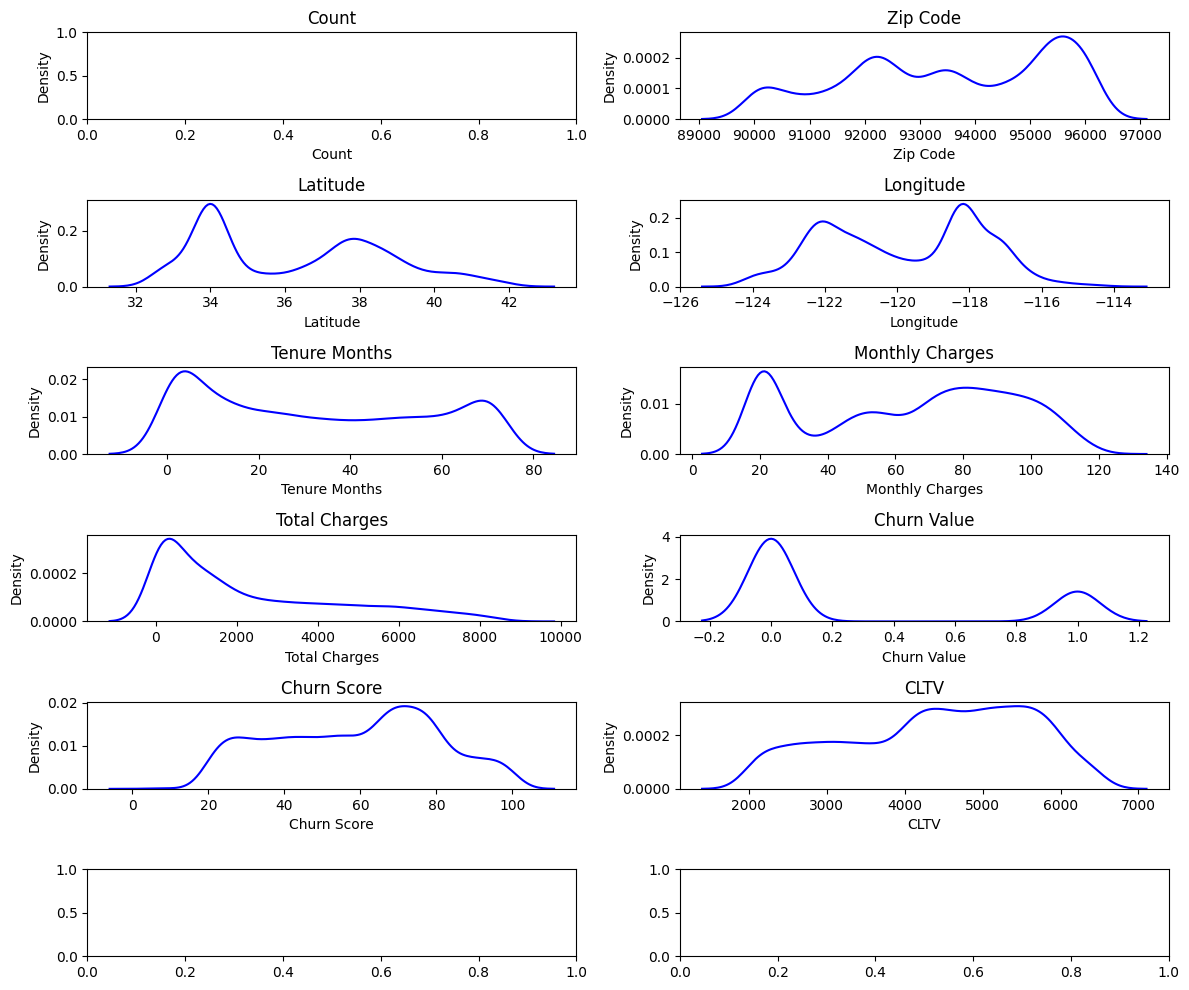

In [83]:
n = len(numeric_features)
fig, axes = plt.subplots(nrows=(n // 2) + 1, ncols=2, figsize=(12, 10))
axes = axes.flatten() # Flat list mein convert karna taaki loop chal sake

for i, col in enumerate(numeric_features):
    sns.kdeplot(x=df[col], color='blue', ax=axes[i])
    axes[i].set_title(col)

# Agar koi extra empty plot ho toh usse hide kar dein
if n % 2 != 0:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Categorical Features

In [84]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


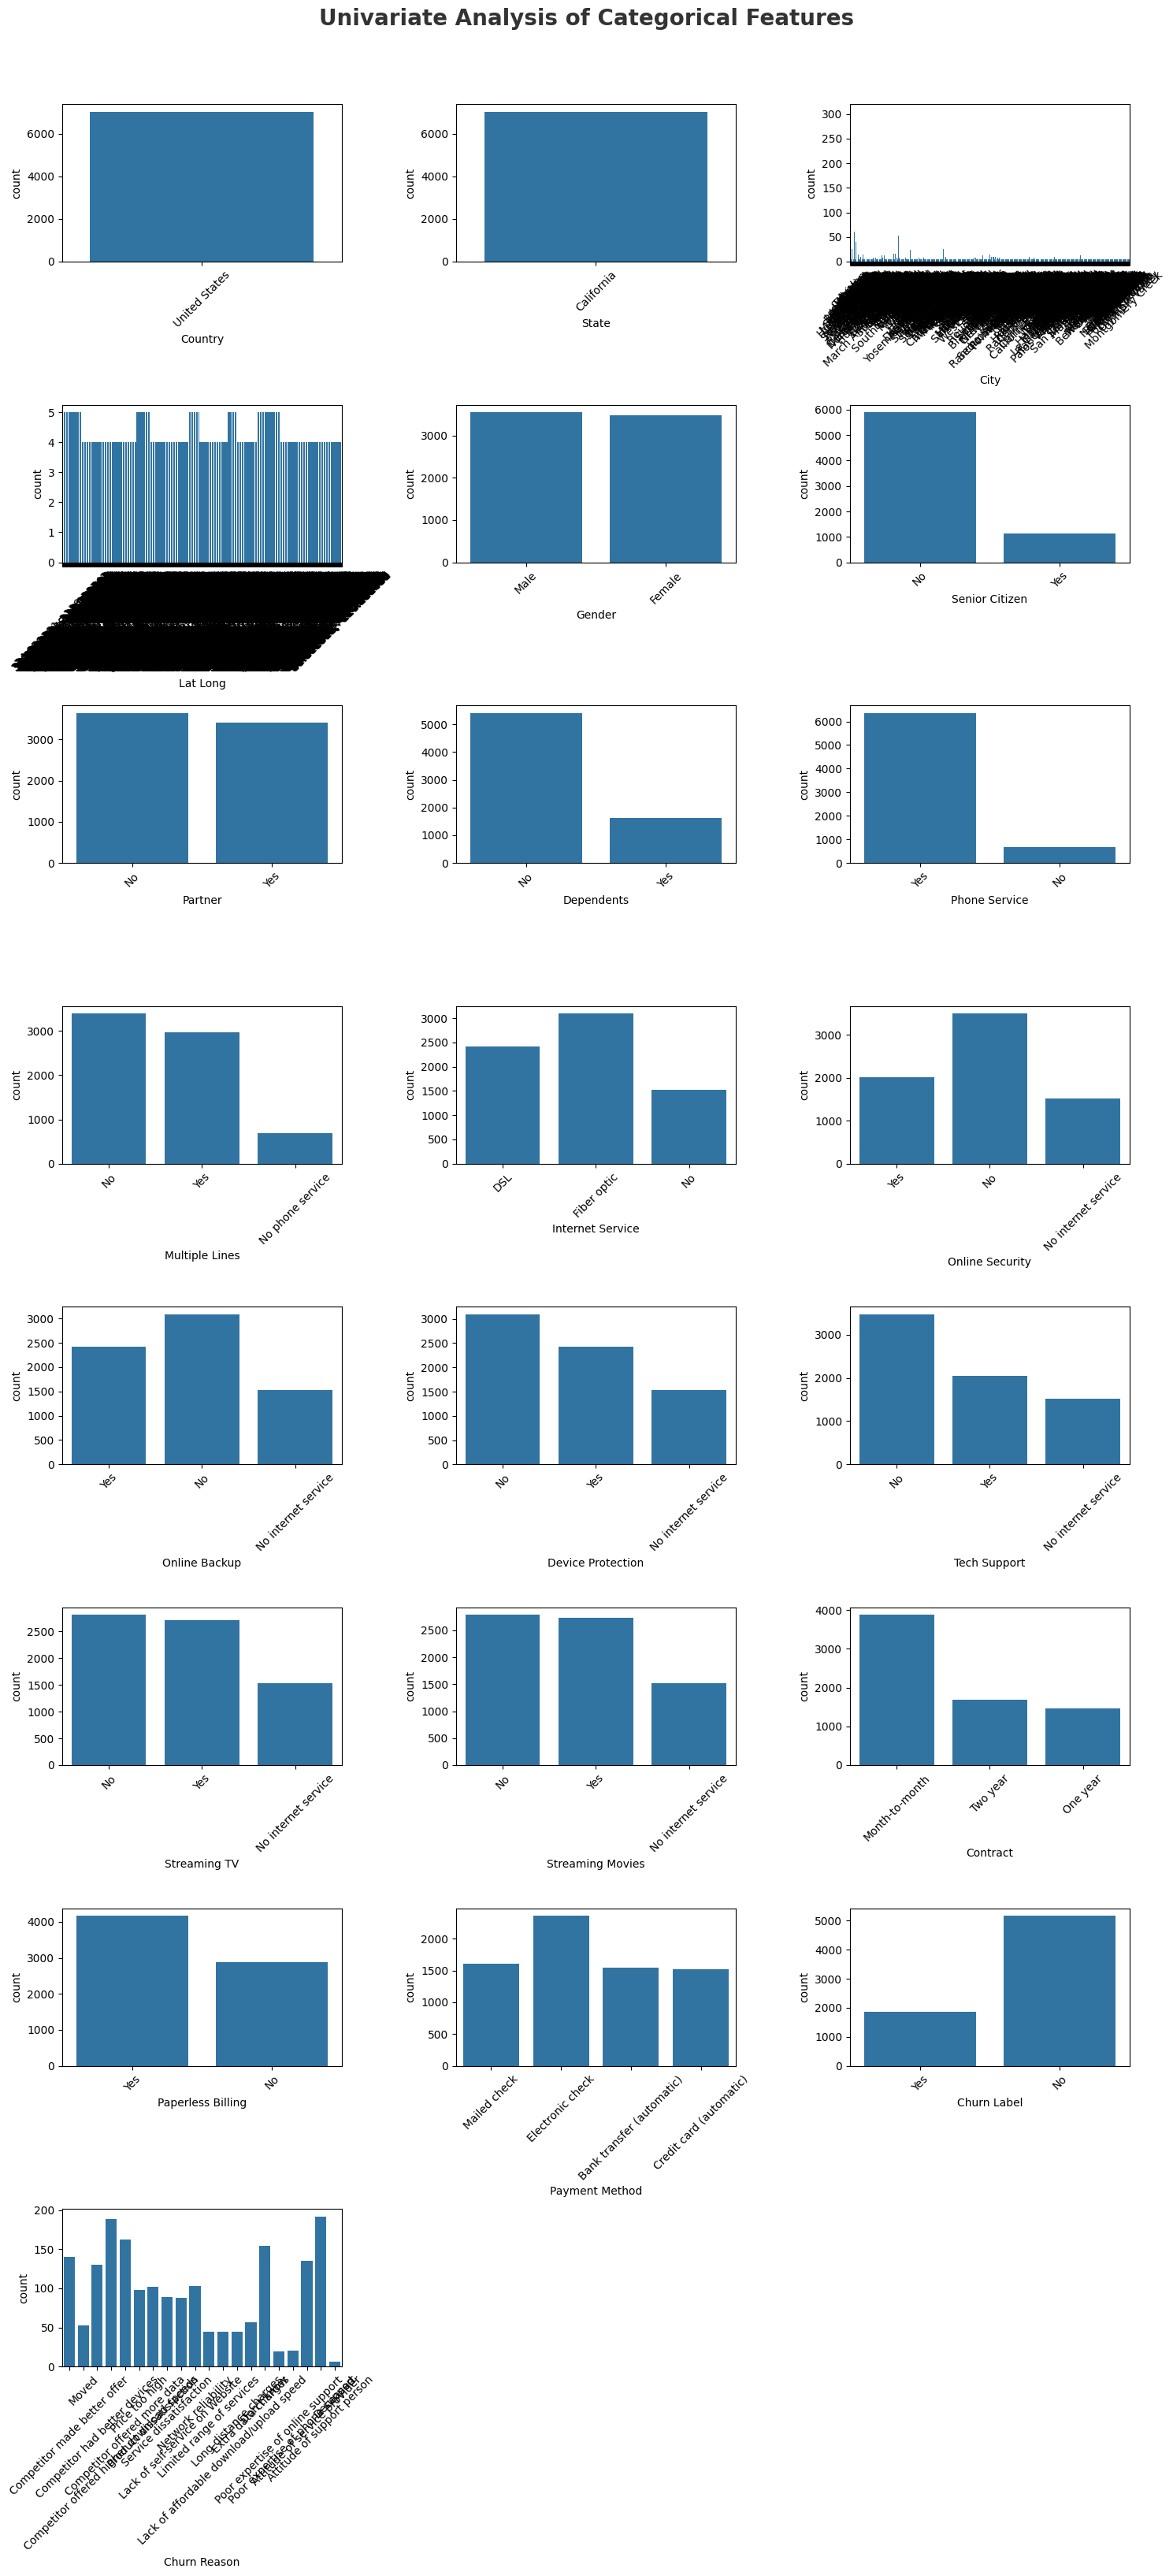

In [86]:
import math

n = len(categorical_features)
cols = 3
rows = math.ceil(n / cols)  # Dynamic rows calculation

plt.figure(figsize=(15, rows * 4)) # Height ko features ke hisaab se adjust karein
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.02)

for i, col in enumerate(categorical_features):
    plt.subplot(rows, cols, i+1)
    sns.countplot(x=df[col])
    plt.xlabel(col)
    plt.xticks(rotation=45) # Labels overlapping se bachne ke liye

plt.tight_layout()
plt.show()

# Multivariate Analysis

In [87]:
discrete_features=[feature for feature in numeric_features if len(df[feature].unique())<=25]

continuous_features=[feature for feature in numeric_features if len(df[feature].unique()) > 25]

print('We have {} discrete features : {}'.format(len(discrete_features), discrete_features))
print('\nWe have {} continuous_features : {}'.format(len(continuous_features), continuous_features))

We have 2 discrete features : ['Count', 'Churn Value']

We have 8 continuous_features : ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']


# Check Multicollinearity in Numerical features

In [89]:
df.head(1)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer


# Check Multicollinearity for Categorical features

In [90]:
from scipy.stats import chi2_contingency

target_col = 'Churn Label' # Aap 'Churn Value' bhi use kar sakte hain
features_to_test = [col for col in categorical_features if col not in ['CustomerID', target_col]]

chi2_results = []

for feature in features_to_test:
    # 2. Crosstabulation
    contingency_table = pd.crosstab(df[target_col], df[feature])
    
    # 3. Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # 4. Decision
    hypothesis = 'Reject Null Hypothesis' if p < 0.05 else 'Fail to Reject Null Hypothesis'
    
    chi2_results.append({
        'Column': feature,
        'P-Value': round(p, 4),
        'Hypothesis Result': hypothesis
    })

# 5. Result DataFrame
result_df = pd.DataFrame(chi2_results)

# P-Value ke base par sort karein taaki strongest features upar dikhein
result_df = result_df.sort_values(by='P-Value')

result_df

,Column,P-Value,Hypothesis Result
6,Partner,0.0000,Reject Null Hypothesis
7,Dependents,0.0000,Reject Null Hypothesis
5,Senior Citizen,0.0000,Reject Null Hypothesis
14,Tech Support,0.0000,Reject Null Hypothesis
12,Online Backup,0.0000,Reject Null Hypothesis
13,Device Protection,0.0000,Reject Null Hypothesis
10,Internet Service,0.0000,Reject Null Hypothesis
11,Online Security,0.0000,Reject Null Hypothesis
15,Streaming TV,0.0000,Reject Null Hypothesis
18,Paperless Billing,0.0000,Reject Null Hypothesis


# Checking Null Values

In [91]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [92]:
continues_features=[feature for feature in numeric_features if len(df[feature].unique())>=10]
print('Num of continues features :',continues_features)

Num of continues features : ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']


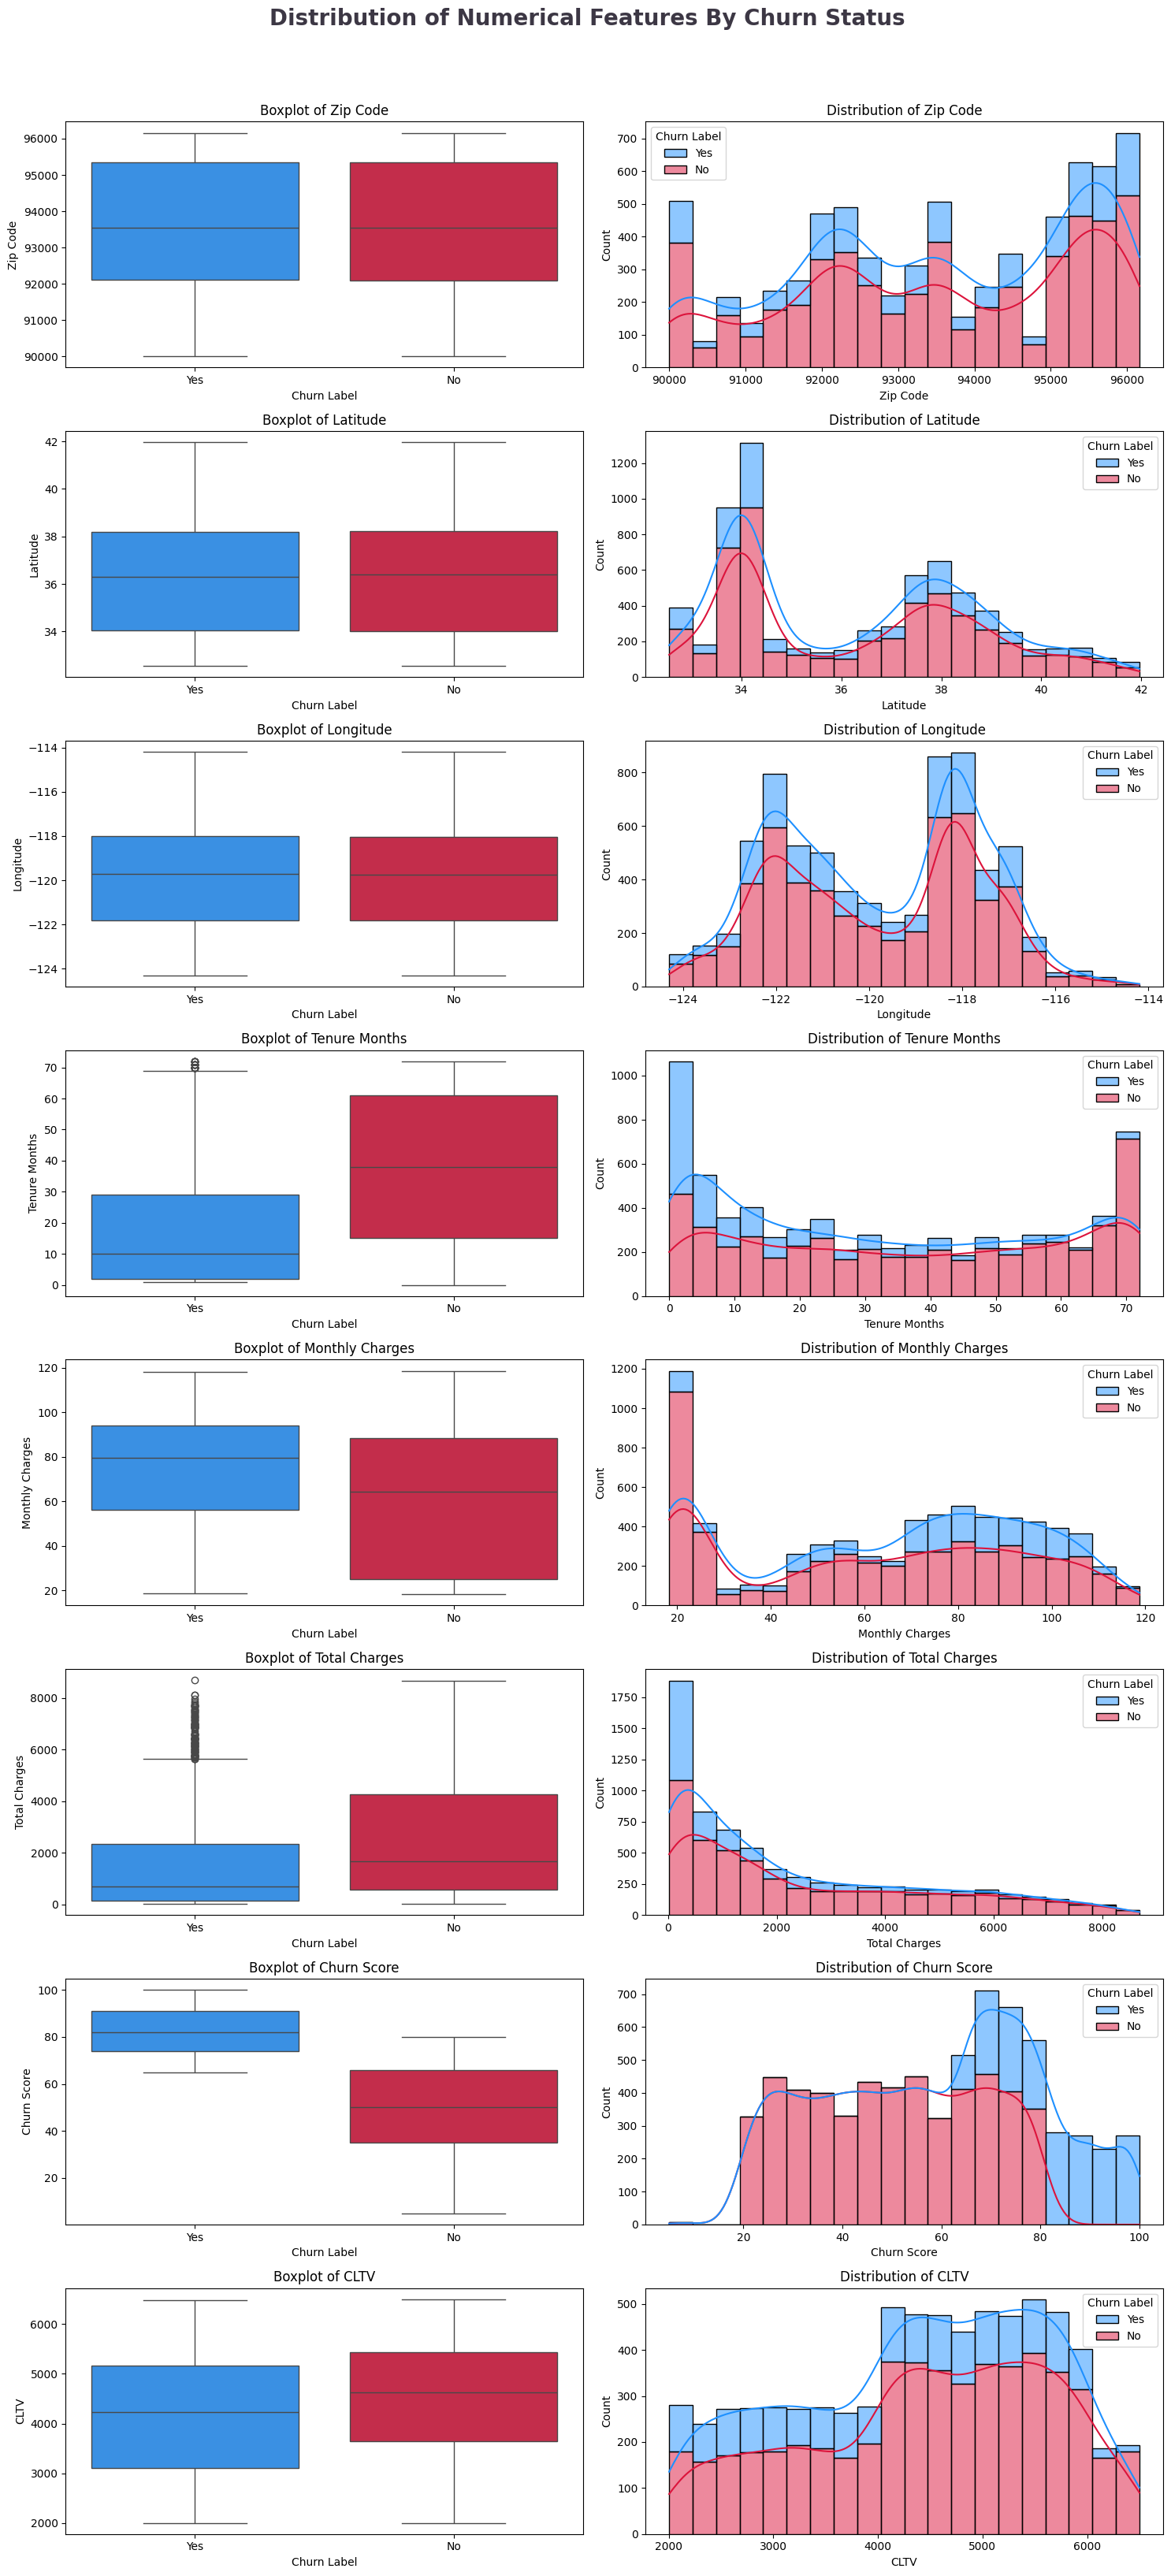

In [95]:
# 1. 8 features hain, toh 8 rows banayein (1 row = 1 boxplot + 1 histplot)
n = len(continues_features)
fig, axes = plt.subplots(n, 2, figsize=(15, n * 4)) 

# Agar sirf 1 feature ho toh axes 1D hota hai, usse 2D mein badlein
if n == 1:
    axes = np.array([axes])

fig.suptitle('Distribution of Numerical Features By Churn Status', color='#3C3744',
             fontsize=20, fontweight='bold', y=1.02)

for i, col in enumerate(continues_features):
    # Boxplot (Left column)
    sns.boxplot(data=df, x=target, y=col, hue=target, palette=clr1, ax=axes[i, 0])
    axes[i, 0].set_title(f'Boxplot of {col}')
    
    # Histogram/KDE plot (Right column)
    sns.histplot(data=df, x=col, hue=target, bins=20, kde=True, 
                 multiple='stack', palette=clr1, ax=axes[i, 1])
    axes[i, 1].set_title(f'Distribution of {col}')

fig.tight_layout()
plt.show()

# Visualization

# Visualize the Target Feature

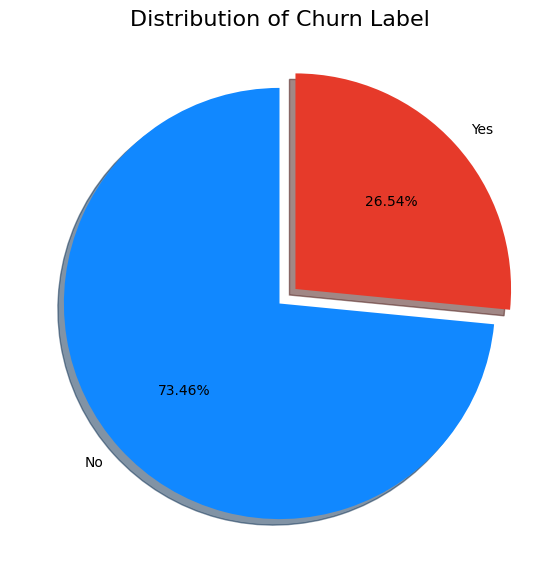

In [96]:
target_col = 'Churn Label' 

# 2. Percentage calculation
percentage = df[target_col].value_counts(normalize=True) * 100
labels = percentage.index  # Automatically "Yes" aur "No" labels le lega

# 3. Pie Chart
fig, ax = plt.subplots(figsize=(10, 7))
explode = (0, 0.1)  # Minority class ko thoda bahar nikalne ke liye
colors = ['#1188ff', '#e63a2a']

ax.pie(percentage, labels=labels, startangle=90,
       autopct='%1.2f%%', explode=explode, shadow=True, colors=colors)

ax.set_title(f'Distribution of {target_col}', fontsize=16)
plt.show()